In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path.cwd().parent

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Input:", INTERIM_DATA_DIR)
print("Output:", PROCESSED_DATA_DIR)

Project: e:\Internship\Guard_Patrol_Anomaly_Detection
Input: e:\Internship\Guard_Patrol_Anomaly_Detection\data\interim
Output: e:\Internship\Guard_Patrol_Anomaly_Detection\data\processed


# Main dataset load

In [8]:
input_path = INTERIM_DATA_DIR / "geolife_gps_osm_features.parquet"
df = pd.read_parquet(input_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (916, 14)

Columns:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   guard_id                  916 non-null    object        
 1   timestamp                 916 non-null    datetime64[ns]
 2   latitude                  916 non-null    float64       
 3   longitude                 916 non-null    float64       
 4   altitude_ft               916 non-null    int64         
 5   time_gap_seconds          915 non-null    float64       
 6   distance_from_previous_m  916 non-null    float64       
 7   speed_kmh                 915 non-null    float64       
 8   gps_jump                  916 non-null    bool          
 9   distance_to_road_m        916 non-null    float64       
 10  road_match_status         916 non-null    category      
 11  highway                   916 non-null    object        
 12  maxspeed              

In [10]:
print(df.describe(include="all").T)

                          count unique          top freq  \
guard_id                    916      1          000  916   
timestamp                   916    NaN          NaN  NaN   
latitude                  916.0    NaN          NaN  NaN   
longitude                 916.0    NaN          NaN  NaN   
altitude_ft               916.0    NaN          NaN  NaN   
time_gap_seconds          915.0    NaN          NaN  NaN   
distance_from_previous_m  916.0    NaN          NaN  NaN   
speed_kmh                 915.0    NaN          NaN  NaN   
gps_jump                    916      2        False  915   
distance_to_road_m        916.0    NaN          NaN  NaN   
road_match_status           916      4         GOOD  568   
highway                     916     12  residential  250   
maxspeed                      0      0          NaN  NaN   
length                    916.0    NaN          NaN  NaN   

                                                   mean                  min  \
guard_id           

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)
missing_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})
print(missing_report)

                          missing_count  missing_percent
maxspeed                            916        100.00000
time_gap_seconds                      1          0.10917
speed_kmh                             1          0.10917
latitude                              0          0.00000
timestamp                             0          0.00000
guard_id                              0          0.00000
altitude_ft                           0          0.00000
longitude                             0          0.00000
gps_jump                              0          0.00000
distance_from_previous_m              0          0.00000
distance_to_road_m                    0          0.00000
road_match_status                     0          0.00000
highway                               0          0.00000
length                                0          0.00000


## Divide Columns into Columns

In [13]:
gps_columns = [
    "guard_id",
    "timestamp",
    "latitude",
    "longitude",
    "altitude_ft"
]
osm_columns = [
    "distance_to_road_m",
    "road_match_status",
    "highway",
    "length",
    "maxspeed",
    "surface",
    "lit",
    "sidewalk"
]
print("GPS columns available:")
print([c for c in gps_columns if c in df.columns])
print("\nOSM columns available:")
print([c for c in osm_columns if c in df.columns])

GPS columns available:
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft']

OSM columns available:
['distance_to_road_m', 'road_match_status', 'highway', 'length', 'maxspeed']


In [14]:
categorical_osm = [
    "highway",
    "surface",
    "lit",
    "sidewalk"
]
for col in categorical_osm:
    if col in df.columns:
        df[col] = df[col].fillna("UNKNOWN")

In [15]:
numeric_missing = df.select_dtypes(
    include=np.number
).isna().sum()
print(
    numeric_missing[
        numeric_missing > 0
    ].sort_values(ascending=False)
)

time_gap_seconds    1
speed_kmh           1
dtype: int64


# Check Context of missing Values

In [16]:
missing_speed_gap = df[
    df["time_gap_seconds"].isna() |
    df["speed_kmh"].isna()
]
print(missing_speed_gap.T)

                                            0
guard_id                                  000
timestamp                 2008-10-23 02:53:04
latitude                            39.984702
longitude                          116.318417
altitude_ft                               492
time_gap_seconds                          NaN
distance_from_previous_m                  0.0
speed_kmh                                 NaN
gps_jump                                False
distance_to_road_m                   5.513269
road_match_status                        GOOD
highway                              tertiary
maxspeed                                 None
length                                  401.0


# Check Previous nd next rows

In [17]:
idx = missing_speed_gap.index[0]
print(
    df.loc[
        max(0, idx - 2): idx + 2,
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "time_gap_seconds",
            "speed_kmh"
        ]])

  guard_id           timestamp   latitude   longitude  time_gap_seconds  \
0      000 2008-10-23 02:53:04  39.984702  116.318417               NaN   
1      000 2008-10-23 02:53:10  39.984683  116.318450               6.0   
2      000 2008-10-23 02:53:15  39.984686  116.318417               5.0   

   speed_kmh  
0        NaN  
1   2.112417  
2   2.043534  


In [18]:
print(
    df[
        df["time_gap_seconds"].isna() |
        df["speed_kmh"].isna()
    ][
        [
            "guard_id",
            "timestamp",
            "latitude",
            "longitude",
            "time_gap_seconds",
            "speed_kmh"
        ]])

  guard_id           timestamp   latitude   longitude  time_gap_seconds  \
0      000 2008-10-23 02:53:04  39.984702  116.318417               NaN   

   speed_kmh  
0        NaN  


In [19]:
print("Missing time_gap_seconds:", df["time_gap_seconds"].isna().sum())
print("Missing speed_kmh:", df["speed_kmh"].isna().sum())

Missing time_gap_seconds: 1
Missing speed_kmh: 1


In [20]:
first_record = df.loc[
    df.groupby("guard_id")["timestamp"].idxmin()
]

print(
    first_record[
        [
            "guard_id",
            "timestamp",
            "time_gap_seconds",
            "speed_kmh"
        ]
    ].head()
)

  guard_id           timestamp  time_gap_seconds  speed_kmh
0      000 2008-10-23 02:53:04               NaN        NaN


# Check Categorical Column replacement

In [21]:
for col in categorical_osm:
    if col in df.columns:
        print(
            f"\n{col}:",
            df[col].isna().sum(),
            "missing")


highway: 0 missing


In [22]:
# First GPS point of each guard has no previous point,
# therefore time gap and speed are naturally undefined.

df["time_gap_seconds"] = df["time_gap_seconds"].fillna(0)
df["speed_kmh"] = df["speed_kmh"].fillna(0)

print(
    df[
        ["time_gap_seconds", "speed_kmh"]
    ].isna().sum()
)

time_gap_seconds    0
speed_kmh           0
dtype: int64


In [23]:
df["is_first_point"] = (
    df.groupby("guard_id").cumcount() == 0
).astype(int)

In [24]:
df["maxspeed_available"] = (
    df["maxspeed"].notna()
).astype(int)

df["maxspeed"] = df["maxspeed"].fillna("UNKNOWN")

In [25]:
print(df["maxspeed"].value_counts(dropna=False).head(10))

maxspeed
UNKNOWN    916
Name: count, dtype: int64


In [26]:
missing_after = (
    df.isna()
      .sum()
      .sort_values(ascending=False))
missing_after_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False))
missing_after_report = pd.DataFrame({
    "missing_count": missing_after,
    "missing_percent": missing_after_percent
})
print(missing_after_report)

                          missing_count  missing_percent
guard_id                              0              0.0
timestamp                             0              0.0
latitude                              0              0.0
longitude                             0              0.0
altitude_ft                           0              0.0
time_gap_seconds                      0              0.0
distance_from_previous_m              0              0.0
speed_kmh                             0              0.0
gps_jump                              0              0.0
distance_to_road_m                    0              0.0
road_match_status                     0              0.0
highway                               0              0.0
maxspeed                              0              0.0
length                                0              0.0
is_first_point                        0              0.0
maxspeed_available                    0              0.0


## Visualization

In [27]:
df = pd.read_parquet(
    INTERIM_DATA_DIR / "geolife_gps_osm_features.parquet"
)

print(df.shape)
print(df.columns.tolist())

(916, 14)
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


In [28]:
numeric_cols = [
    "altitude_ft",
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "length"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
altitude_ft,916.0,426.938865,1269.647794,-407.000000,130.000000,153.000000,206.250000,7584.000000
time_gap_seconds,915.0,32.724590,624.355707,1.000000,5.000000,5.000000,5.000000,18453.000000
distance_from_previous_m,916.0,16.392717,84.842050,0.000000,4.665800,10.494398,16.027460,1817.893113
speed_kmh,915.0,8.049921,10.079986,0.000000,3.270079,7.307210,11.412784,218.147174
distance_to_road_m,916.0,13.579800,16.865519,0.007636,3.327606,7.186341,15.369943,73.486863
length,916.0,453.228166,444.002808,9.000000,95.000000,345.000000,535.000000,1711.000000


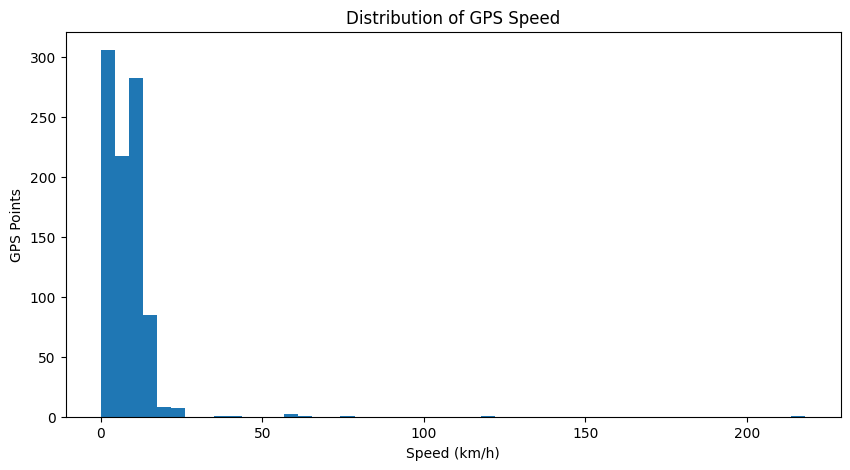

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["speed_kmh"],
    bins=50)
plt.xlabel("Speed (km/h)")
plt.ylabel("GPS Points")
plt.title("Distribution of GPS Speed")
plt.show()

## Time Gap

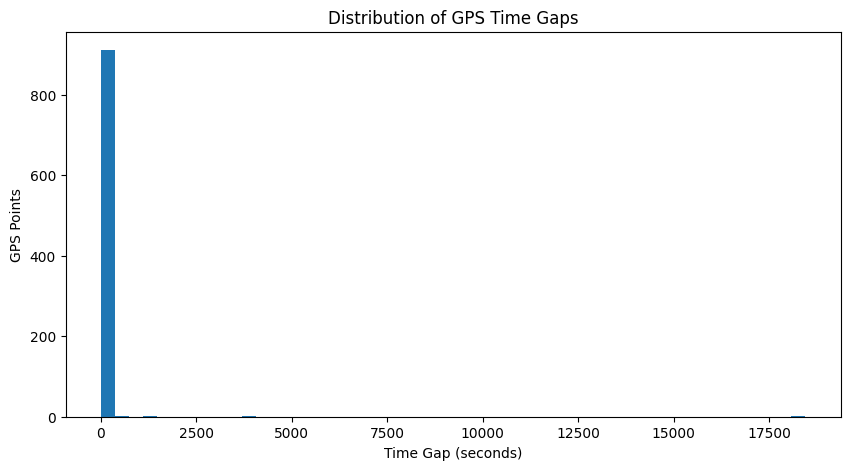

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(
    df["time_gap_seconds"],
    bins=50)
plt.xlabel("Time Gap (seconds)")
plt.ylabel("GPS Points")
plt.title("Distribution of GPS Time Gaps")
plt.show()

# Distance BETWEEN GPS Points 

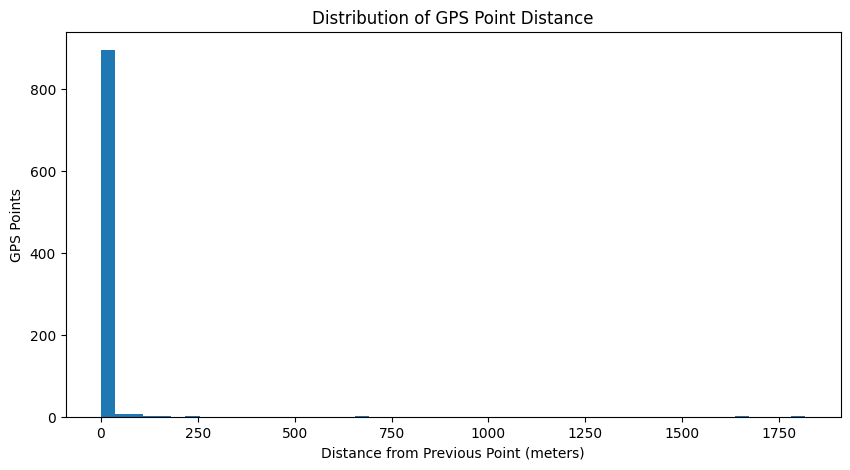

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["distance_from_previous_m"],
    bins=50)
plt.xlabel("Distance from Previous Point (meters)")
plt.ylabel("GPS Points")
plt.title("Distribution of GPS Point Distance")
plt.show()

# Distance From Road

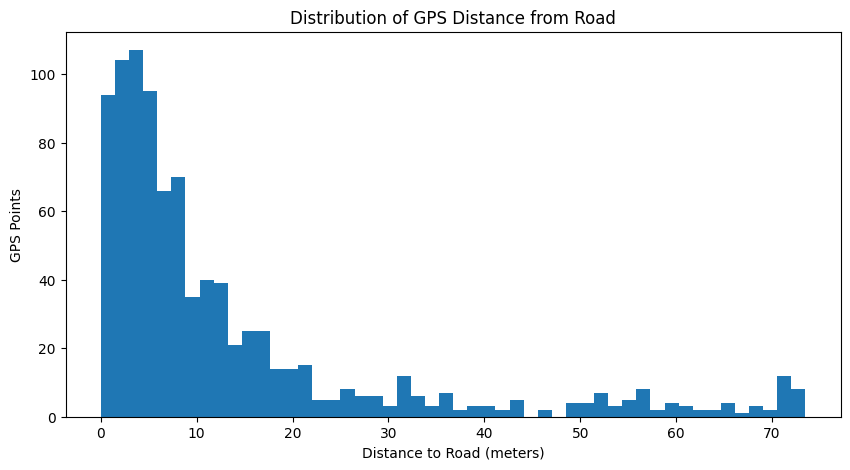

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(
    df["distance_to_road_m"],
    bins=50)
plt.xlabel("Distance to Road (meters)")
plt.ylabel("GPS Points")
plt.title("Distribution of GPS Distance from Road")
plt.show()

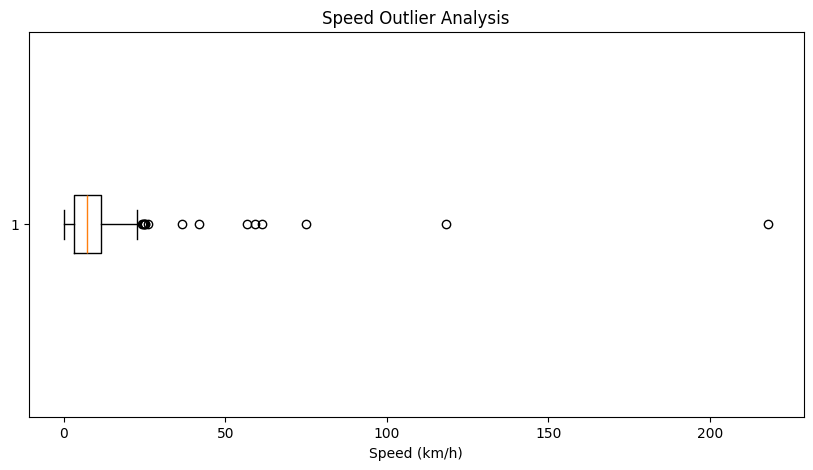

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    df["speed_kmh"].dropna(),
    vert=False)
plt.xlabel("Speed (km/h)")
plt.title("Speed Outlier Analysis")
plt.show()

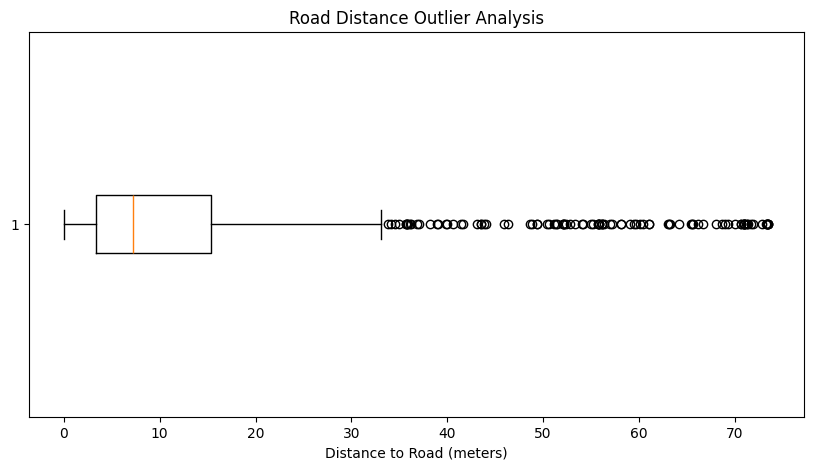

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    df["distance_to_road_m"].dropna(),
    vert=False)
plt.xlabel("Distance to Road (meters)")
plt.title("Road Distance Outlier Analysis")
plt.show()

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
PROJECT_DIR = Path.cwd().parent
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
df = pd.read_parquet(
    INTERIM_DATA_DIR / "geolife_gps_osm_features.parquet")
print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (916, 14)
['guard_id', 'timestamp', 'latitude', 'longitude', 'altitude_ft', 'time_gap_seconds', 'distance_from_previous_m', 'speed_kmh', 'gps_jump', 'distance_to_road_m', 'road_match_status', 'highway', 'maxspeed', 'length']


# Speed vs Distance Relationship

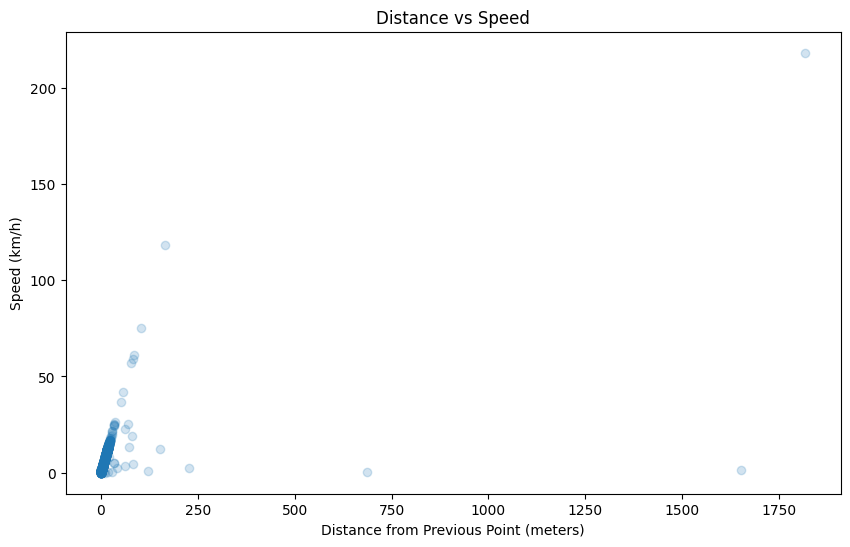

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["distance_from_previous_m"],
    df["speed_kmh"],
    alpha=0.2)
plt.xlabel("Distance from Previous Point (meters)")
plt.ylabel("Speed (km/h)")
plt.title("Distance vs Speed")
plt.show()

# Time Gap vs Speed

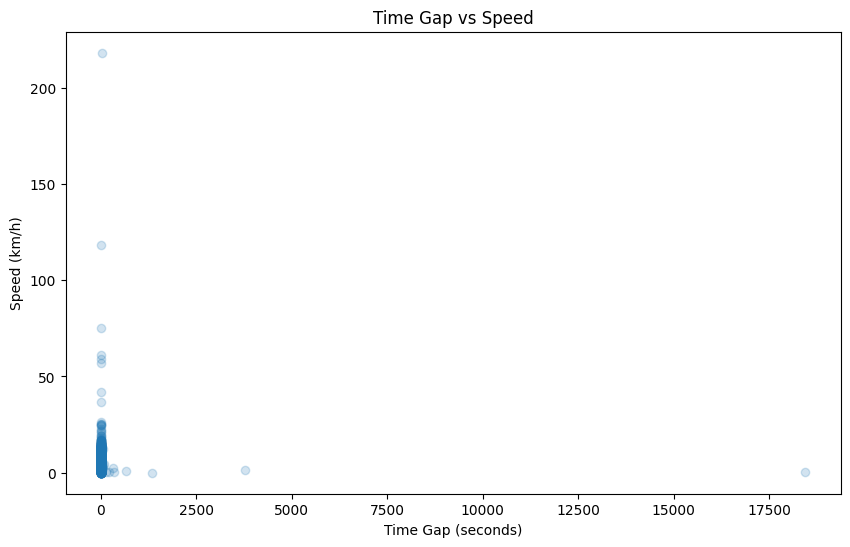

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["time_gap_seconds"],
    df["speed_kmh"],
    alpha=0.2)
plt.xlabel("Time Gap (seconds)")
plt.ylabel("Speed (km/h)")
plt.title("Time Gap vs Speed")
plt.show()

# Distance to Road vs Speed

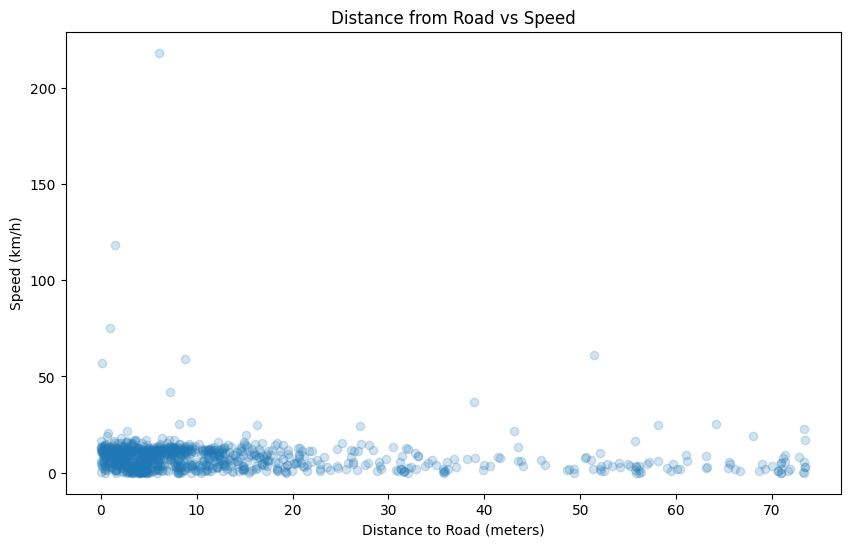

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["distance_to_road_m"],
    df["speed_kmh"],
    alpha=0.2)
plt.xlabel("Distance to Road (meters)")
plt.ylabel("Speed (km/h)")
plt.title("Distance from Road vs Speed")
plt.show()

# Road Match Status vs Speed

categorical relationship

In [39]:
road_speed = (
    df.groupby("road_match_status")["speed_kmh"]
      .describe()
)
print(road_speed)

                   count      mean        std  min       25%       50%  \
road_match_status                                                        
GOOD               567.0  8.820547  11.857700  0.0  3.836314  8.610265   
ACCEPTABLE         227.0  7.395504   4.668351  0.0  3.474098  7.051070   
FAR                 51.0  5.431150   6.251713  0.0  1.679716  3.386197   
VERY_FAR            70.0  5.837997   8.747520  0.0  1.845765  3.405003   

                         75%         max  
road_match_status                         
GOOD               11.755122  218.147174  
ACCEPTABLE         11.259115   24.902505  
FAR                 7.394002   36.703098  
VERY_FAR            6.016406   61.286863  


C:\Users\World\AppData\Local\Temp\ipykernel_22504\768565562.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("road_match_status")["speed_kmh"]


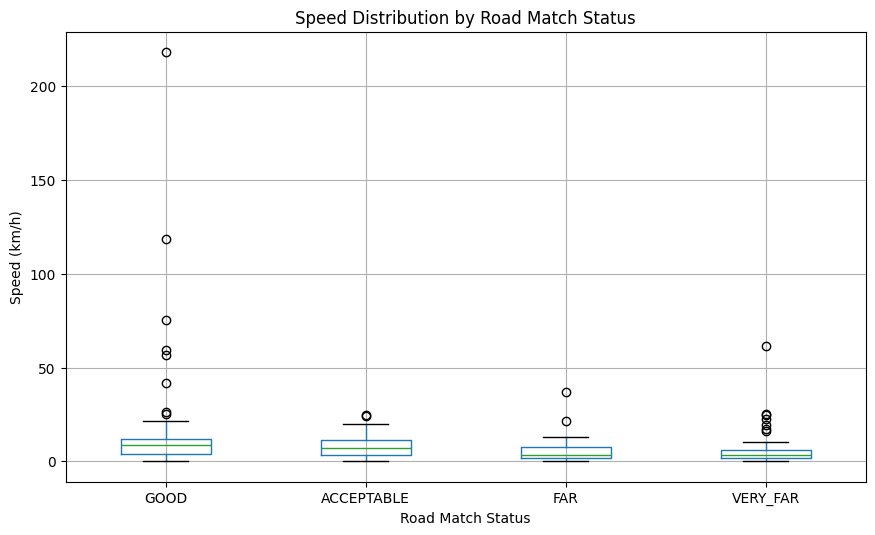

In [ ]:
df.boxplot(
    column="speed_kmh",
    by="road_match_status",
    figsize=(10, 6))
plt.title("Speed Distribution by Road Match Status")
plt.suptitle("")
plt.xlabel("Road Match Status")
plt.ylabel("Speed (km/h)")
plt.show()

## Correlation Matrix

Overall relationship of all variables

In [41]:
numeric_cols = [
    "time_gap_seconds",
    "distance_from_previous_m",
    "speed_kmh",
    "distance_to_road_m",
    "altitude_ft",
    "length"]
correlation = df[numeric_cols].corr()
print(correlation.round(2))

                          time_gap_seconds  distance_from_previous_m  \
time_gap_seconds                      1.00                      0.39   
distance_from_previous_m              0.39                      1.00   
speed_kmh                            -0.03                      0.55   
distance_to_road_m                   -0.03                     -0.02   
altitude_ft                          -0.00                      0.01   
length                               -0.02                     -0.03   

                          speed_kmh  distance_to_road_m  altitude_ft  length  
time_gap_seconds              -0.03               -0.03        -0.00   -0.02  
distance_from_previous_m       0.55               -0.02         0.01   -0.03  
speed_kmh                      1.00               -0.10        -0.06    0.08  
distance_to_road_m            -0.10                1.00         0.10   -0.20  
altitude_ft                   -0.06                0.10         1.00   -0.16  
length               

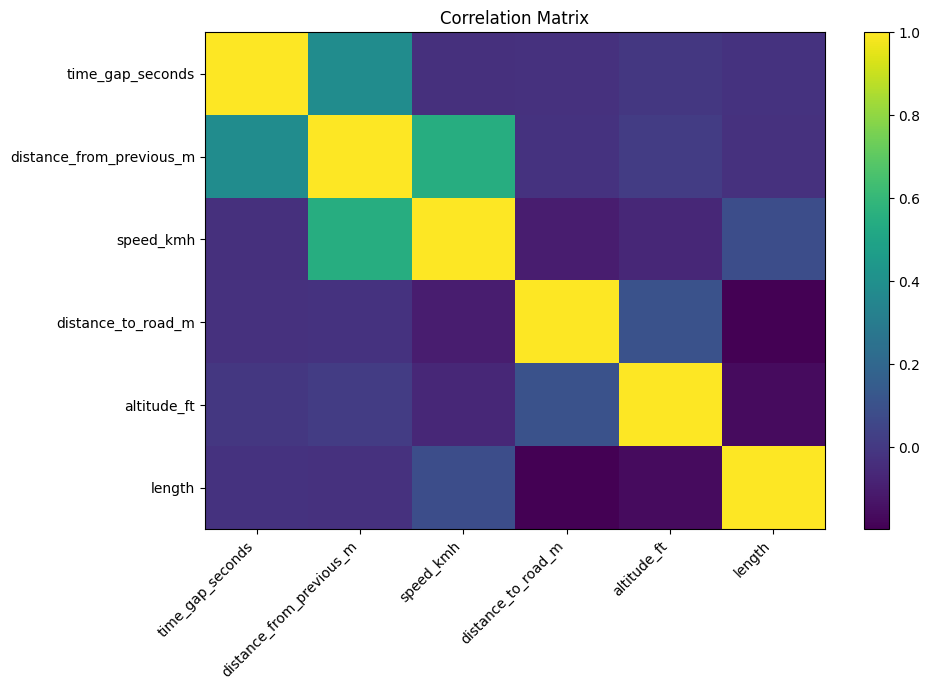

In [42]:
# Visualization

plt.figure(figsize=(10, 7))
plt.imshow(
    correlation,
    aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right")
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# GPS Jump Analysis

gps_jump or movement features relationship

In [43]:
print(df["gps_jump"].value_counts())

gps_jump
False    915
True       1
Name: count, dtype: int64


In [44]:
print(
    df["gps_jump"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2))

gps_jump
False    99.89
True      0.11
Name: proportion, dtype: float64


In [45]:
gps_jumps = df[df["gps_jump"] == True]
print("GPS jump points:", len(gps_jumps))
print(
    gps_jumps[
        [
            "guard_id",
            "timestamp",
            "distance_from_previous_m",
            "time_gap_seconds",
            "speed_kmh",
            "distance_to_road_m"
        ]
    ].head(20))

GPS jump points: 1
    guard_id           timestamp  distance_from_previous_m  time_gap_seconds  \
150      000 2008-10-23 04:08:42               1817.893113              30.0   

      speed_kmh  distance_to_road_m  
150  218.147174            6.030698  
